# GLMM: Feature × Ambiguity Interaction

**Question**: Does ambiguity *moderate* how individual gaze/physio features predict investment decisions?

Notebook 11b showed that 11 gaze features are significantly driven by ambiguity (Direction A),
but they were tested as main effects in Direction B. Here we add `feature × ambiguity`
interaction terms to the ConditionalLogit model:

```
outcome ~ feature_z + ambiguity_z + feature_z:ambiguity_z + controls + (subject FE)
```

A significant interaction means the feature's predictive relationship with choice
is **stronger or weaker depending on ambiguity** — i.e., ambiguity moderates the
neural-to-behavioural coupling, not just its magnitude.

**Scope**: We test this for all 11 ambiguity-significant gaze features, plus
a secondary scan of EEG and pupil features as a null comparison.

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import norm
import statsmodels.formula.api as smf
from statsmodels.discrete.conditional_models import ConditionalLogit
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)
OUT = Path('../../data/results/main/statistical_analyses/interaction')
OUT.mkdir(parents=True, exist_ok=True)


## 1. Load Data

In [2]:
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)
merged_df   = feature_data['merged_df'].copy()
physio_cols = feature_data['physio_cols']
gaze_cols   = feature_data['gaze_cols']

with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)
eeg_df   = eeg_data['eeg_features_df'].copy()
eeg_cols = eeg_data['feature_columns']

behavior_keep = ['subject_id', 'trial_id', 'outcome',
                 'ambiguity', 'ev_difference', 'decision_time',
                 'prev_outcome', 'running_invest_rate']

print(f"Trials: {len(merged_df)}, Subjects: {merged_df['subject_id'].nunique()}")


Trials: 12107, Subjects: 102


## 2. Helpers

In [3]:
def zscore_cols(df, cols):
    df = df.copy()
    for c in cols:
        mu, sd = df[c].mean(), df[c].std()
        df[f'{c}_z'] = (df[c] - mu) / sd if sd > 0 else 0.0
    return df


def fit_clogit(outcome, predictors_df, groups):
    df_fit = predictors_df.copy()
    df_fit['_outcome'] = outcome.values
    df_fit['_group']   = groups.values
    var_mask = df_fit.groupby('_group')['_outcome'].transform('std') > 0
    df_fit = df_fit[var_mask].reset_index(drop=True)
    if len(df_fit) == 0 or df_fit['_group'].nunique() < 5:
        return None
    try:
        model  = ConditionalLogit(df_fit['_outcome'],
                                  df_fit.drop(columns=['_outcome', '_group']),
                                  groups=df_fit['_group'])
        return model.fit(disp=False)
    except Exception:
        return None


CTRL_COLS = ['ev_difference_z', 'prev_outcome', 'running_invest_rate_z', 'decision_time_z']

print("Helpers defined.")


Helpers defined.


## 3. Interaction Scan Function

For each feature we fit two ConditionalLogit models and compare:
- **Main-effects model**: `outcome ~ feature_z + ambiguity_z + controls`
- **Interaction model**: adds `feature_z × ambiguity_z`

We extract the interaction coefficient, its SE, p-value, and an LRT
(likelihood-ratio test) comparing the two models.

In [4]:
def interaction_scan(feature_cols, df, label=''):
    rows = []
    for col in feature_cols:
        zcol = f'{col}_z'
        if zcol not in df.columns:
            continue
        interaction_col = f'{zcol}_x_amb'
        df[interaction_col] = df[zcol] * df['ambiguity_z']

        pred_main = df[[zcol, 'ambiguity_z'] + CTRL_COLS].copy()
        pred_int  = df[[zcol, 'ambiguity_z', interaction_col] + CTRL_COLS].copy()

        fit_main = fit_clogit(df['outcome'], pred_main, df['subject_id'])
        fit_int  = fit_clogit(df['outcome'], pred_int,  df['subject_id'])

        if fit_main is None or fit_int is None:
            continue

        beta_main = fit_main.params[zcol]
        beta_int  = fit_int.params[interaction_col]
        se_int    = fit_int.bse[interaction_col]
        p_int     = fit_int.pvalues[interaction_col]

        # LRT: -2 * (llf_main - llf_int) ~ chi2(1)
        from scipy.stats import chi2
        lrt_stat = -2 * (fit_main.llf - fit_int.llf)
        lrt_p    = chi2.sf(lrt_stat, df=1)

        rows.append({
            'feature':     col,
            'beta_main':   beta_main,          # main effect (log-odds)
            'beta_int':    beta_int,            # interaction log-odds
            'se_int':      se_int,
            'p_int':       p_int,
            'lrt_stat':    lrt_stat,
            'lrt_p':       lrt_p,
            'sig_int':     p_int < 0.05,
        })

    out = pd.DataFrame(rows).sort_values('p_int')
    return out

print("interaction_scan() defined.")


interaction_scan() defined.


## 4. Gaze × Ambiguity

Focus: the 11 gaze features that are significantly driven by ambiguity (from notebook 11b).

In [5]:
gaze_model_cols = [c for c in gaze_cols if c not in
                   ['gaze_valid_pct', 'fixation_ratio', 'saccade_ratio', 'saccade_count']]

df_gaze = merged_df[behavior_keep + gaze_model_cols].dropna(subset=gaze_model_cols).copy().reset_index(drop=True)
df_gaze = zscore_cols(df_gaze, ['ambiguity', 'ev_difference', 'decision_time',
                                  'running_invest_rate'] + gaze_model_cols)

print(f"Gaze dataset: {len(df_gaze)} trials, {df_gaze['subject_id'].nunique()} subjects")

gaze_int = interaction_scan(gaze_model_cols, df_gaze, label='Gaze')

print(f"\nGaze × Ambiguity interaction scan ({len(gaze_int)} features):")
print(f"  Significant interactions (p<.05): {gaze_int['sig_int'].sum()} / {len(gaze_int)}")
print()
print(gaze_int[['feature', 'beta_main', 'beta_int', 'se_int', 'p_int', 'lrt_p', 'sig_int']]
      .to_string(index=False))


Gaze dataset: 12107 trials, 102 subjects

Gaze × Ambiguity interaction scan (16 features):
  Significant interactions (p<.05): 3 / 16

               feature  beta_main  beta_int   se_int    p_int    lrt_p  sig_int
         screen_y_mean   0.001134 -0.061868 0.024073 0.010170 0.009962     True
         screen_x_mean  -0.008902  0.052909 0.024760 0.032612 0.032475     True
    gaze_velocity_mean   0.020902 -0.061815 0.030388 0.041934 0.033497     True
          screen_x_std  -0.129053 -0.046337 0.024064 0.054160 0.050467    False
gaze_acceleration_mean   0.024635 -0.056060 0.029426 0.056766 0.045687    False
 gaze_acceleration_std   0.010378 -0.036133 0.024689 0.143324 0.140050    False
          screen_y_std   0.028526 -0.033168 0.024872 0.182357 0.177182    False
     gaze_velocity_std   0.013112 -0.032614 0.024658 0.185949 0.182836    False
            gaze_x_std  -0.733233 -0.034213 0.026627 0.198825 0.199869    False
            gaze_y_std   0.050525  0.023785 0.023685 0.315268 0.3

## 5. Pupil × Ambiguity

In [6]:
pupil_cols = [c for c in physio_cols if c.endswith('_pre')]

df_pupil = merged_df[behavior_keep + pupil_cols].dropna(subset=pupil_cols).copy().reset_index(drop=True)
df_pupil = zscore_cols(df_pupil, ['ambiguity', 'ev_difference', 'decision_time',
                                   'running_invest_rate'] + pupil_cols)

print(f"Pupil dataset: {len(df_pupil)} trials, {df_pupil['subject_id'].nunique()} subjects")

pupil_int = interaction_scan(pupil_cols, df_pupil, label='Pupil')

print(f"\nPupil × Ambiguity interaction scan ({len(pupil_int)} features):")
print(f"  Significant interactions: {pupil_int['sig_int'].sum()} / {len(pupil_int)}")
print()
print(pupil_int[['feature', 'beta_main', 'beta_int', 'se_int', 'p_int', 'lrt_p', 'sig_int']]
      .to_string(index=False))


Pupil dataset: 12107 trials, 102 subjects

Pupil × Ambiguity interaction scan (13 features):
  Significant interactions: 5 / 13

                        feature  beta_main  beta_int   se_int    p_int    lrt_p  sig_int
              eye_asymmetry_pre   0.064612 -0.110409 0.026654 0.000034 0.000022     True
          eye_asymmetry_std_pre   0.057808 -0.129286 0.032173 0.000059 0.000040     True
    pupil_max_dilation_rate_pre  -0.014038 -0.091479 0.029503 0.001931 0.000964     True
     pupil_acceleration_std_pre   0.058624 -0.072507 0.024060 0.002582 0.002327     True
         num_dilation_peaks_pre  -0.034045 -0.055434 0.023374 0.017710 0.017618     True
pupil_max_constriction_rate_pre   0.079321 -0.039965 0.023766 0.092650 0.091513    False
        pupil_velocity_mean_pre   0.125067 -0.039295 0.024524 0.109084 0.108414    False
                  pupil_std_pre   0.202739  0.033033 0.024381 0.175472 0.176170    False
                 pupil_mean_pre   0.036293  0.029117 0.023282 0.211074

## 6. EEG × Ambiguity (Null Comparison)

In [7]:
df_eeg = merged_df[behavior_keep].merge(eeg_df[['trial_id'] + eeg_cols], on='trial_id', how='inner')
df_eeg = df_eeg.dropna(subset=eeg_cols).reset_index(drop=True)
df_eeg = zscore_cols(df_eeg, ['ambiguity', 'ev_difference', 'decision_time',
                                'running_invest_rate'] + eeg_cols)

print(f"EEG dataset: {len(df_eeg)} trials, {df_eeg['subject_id'].nunique()} subjects")

eeg_int = interaction_scan(eeg_cols, df_eeg, label='EEG')

print(f"\nEEG × Ambiguity interaction scan ({len(eeg_int)} features):")
print(f"  Significant interactions: {eeg_int['sig_int'].sum()} / {len(eeg_int)}")
print()
print(eeg_int[['feature', 'beta_main', 'beta_int', 'se_int', 'p_int', 'lrt_p', 'sig_int']]
      .to_string(index=False))


EEG dataset: 5437 trials, 80 subjects

EEG × Ambiguity interaction scan (16 features):
  Significant interactions: 0 / 16

            feature  beta_main  beta_int   se_int    p_int    lrt_p  sig_int
   eeg_Beta_Frontal  -0.048078  0.077368 0.042017 0.065571 0.060356    False
  eeg_Alpha_Frontal  -0.158350  0.047898 0.035533 0.177670 0.182047    False
  eeg_Alpha_Central  -0.130511  0.044837 0.037296 0.229294 0.232959    False
 eeg_Alpha_Parietal  -0.166582  0.039687 0.034584 0.251159 0.255687    False
eeg_Theta_Occipital  -0.025252 -0.028573 0.034365 0.405708 0.402712    False
eeg_Alpha_Occipital  -0.152442  0.027149 0.033516 0.417920 0.420488    False
   eeg_Beta_Central  -0.036170  0.034988 0.044161 0.428195 0.426116    False
 eeg_Beta_Occipital  -0.050813  0.024617 0.032992 0.455569 0.454610    False
  eeg_Beta_Parietal  -0.060457  0.024546 0.033331 0.461477 0.464559    False
  eeg_Theta_Central  -0.086190  0.024129 0.033429 0.470417 0.474994    False
 eeg_Delta_Parietal  -0.023316

## 7. Visualization

Forest plots of interaction coefficients (log-odds of `feature × ambiguity`).
A positive interaction means the feature predicts investing *more strongly* at high ambiguity;
negative means the feature's relationship with choice *attenuates* under ambiguity.

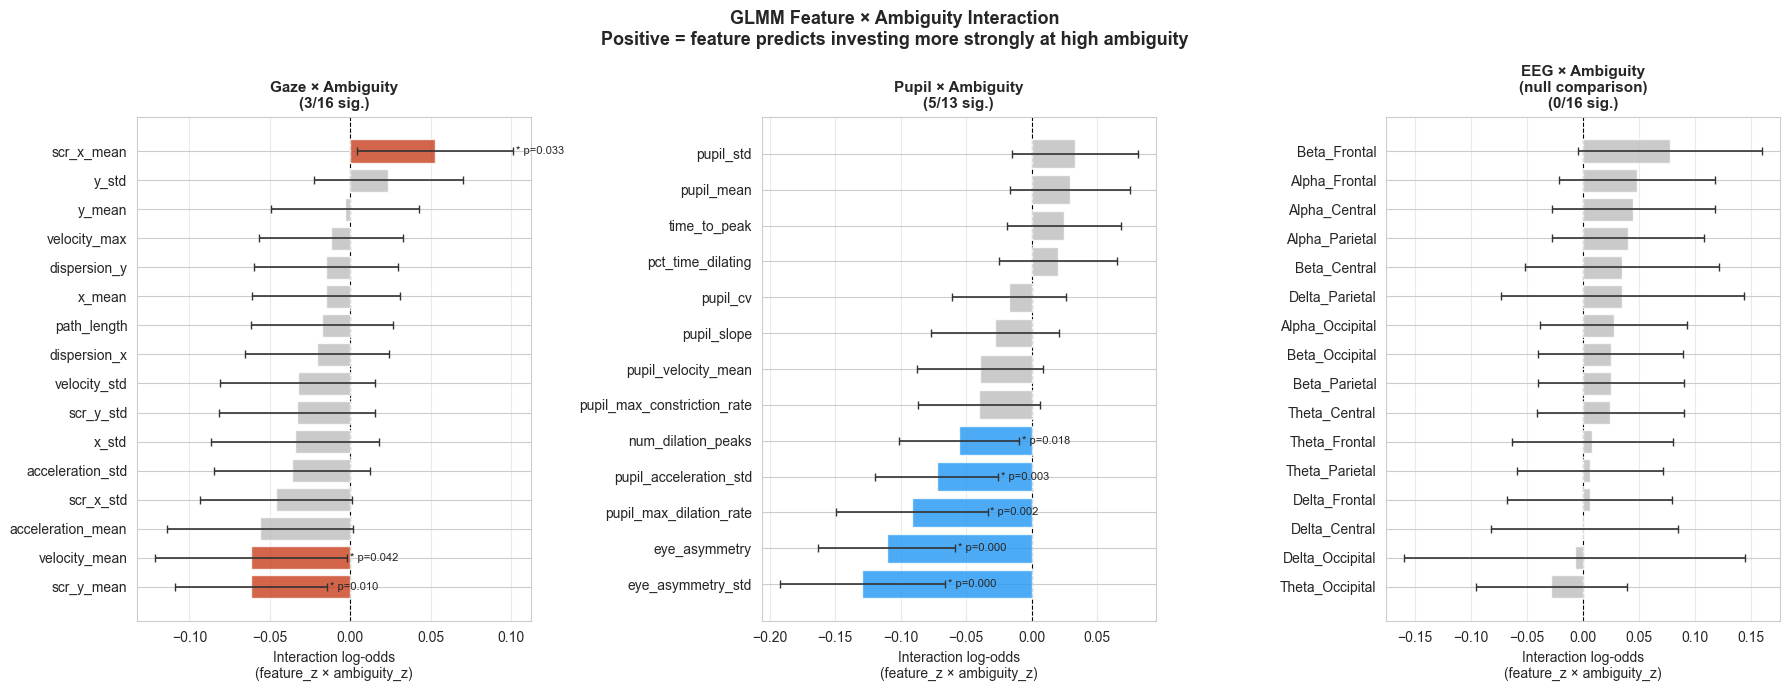

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
panel_data = [
    (gaze_int,  'Gaze × Ambiguity',  '#C73E1D'),
    (pupil_int, 'Pupil × Ambiguity', '#2196F3'),
    (eeg_int,   'EEG × Ambiguity\n(null comparison)', '#A23B72'),
]

for ax, (df_i, title, color) in zip(axes, panel_data):
    df_plot = df_i.sort_values('beta_int').reset_index(drop=True)
    short = [f.replace('gaze_', '').replace('screen_', 'scr_')
               .replace('_pre', '').replace('eeg_', '') for f in df_plot['feature']]
    bar_colors = [color if s else '#BDBDBD' for s in df_plot['sig_int']]
    ax.barh(short, df_plot['beta_int'], color=bar_colors, alpha=0.8, zorder=3)
    ax.errorbar(df_plot['beta_int'], short,
                xerr=1.96 * df_plot['se_int'], fmt='none',
                color='#333', capsize=3, linewidth=1.2, zorder=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    # Annotate significant rows
    for idx, row in df_plot.iterrows():
        if row['sig_int']:
            ax.text(row['beta_int'] + 1.96*row['se_int'] + 0.002, idx,
                    f'* p={row["p_int"]:.3f}', va='center', fontsize=8)
    n_sig = df_plot['sig_int'].sum()
    ax.set_title(f'{title}\n({n_sig}/{len(df_plot)} sig.)', fontweight='bold', fontsize=11)
    ax.set_xlabel('Interaction log-odds\n(feature_z × ambiguity_z)', fontsize=10)
    ax.grid(axis='x', alpha=0.4)

fig.suptitle('GLMM Feature × Ambiguity Interaction\n'
             'Positive = feature predicts investing more strongly at high ambiguity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'glmm_feature_ambiguity_interaction.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Save & Summary

In [9]:
gaze_int['modality']  = 'Gaze'
pupil_int['modality'] = 'Pupil'
eeg_int['modality']   = 'EEG'

all_int = pd.concat([gaze_int, pupil_int, eeg_int], ignore_index=True)
all_int.to_csv(OUT / 'glmm_feature_ambiguity_interactions.csv', index=False)

print("=" * 65)
print("SUMMARY: Feature × Ambiguity Interactions")
print("=" * 65)
for mod_df, label in [(gaze_int, 'Gaze'), (pupil_int, 'Pupil'), (eeg_int, 'EEG')]:
    sig = mod_df[mod_df['sig_int']]
    print(f"\n{label} ({len(mod_df)} features, {len(sig)} sig. interactions):")
    if len(sig):
        print(sig[['feature', 'beta_int', 'p_int']].to_string(index=False))
    else:
        print("  None significant")

print("\nInterpretation:")
print("  Positive β_int: feature predicts INVEST more strongly at HIGH ambiguity")
print("  Negative β_int: feature predicts invest LESS strongly at high ambiguity")
print("  (i.e., the feature-choice coupling attenuates under uncertainty)")


SUMMARY: Feature × Ambiguity Interactions

Gaze (16 features, 3 sig. interactions):
           feature  beta_int    p_int
     screen_y_mean -0.061868 0.010170
     screen_x_mean  0.052909 0.032612
gaze_velocity_mean -0.061815 0.041934

Pupil (13 features, 5 sig. interactions):
                    feature  beta_int    p_int
          eye_asymmetry_pre -0.110409 0.000034
      eye_asymmetry_std_pre -0.129286 0.000059
pupil_max_dilation_rate_pre -0.091479 0.001931
 pupil_acceleration_std_pre -0.072507 0.002582
     num_dilation_peaks_pre -0.055434 0.017710

EEG (16 features, 0 sig. interactions):
  None significant

Interpretation:
  Positive β_int: feature predicts INVEST more strongly at HIGH ambiguity
  Negative β_int: feature predicts invest LESS strongly at high ambiguity
  (i.e., the feature-choice coupling attenuates under uncertainty)
